# Check FastAPI service для pneumothorax segmentation

Этот ноутбук предназначен для демонстрации сервиса в Datasphere, Jupyter и Google Colab.

Что делает ноутбук:
1. при необходимости устанавливает зависимости;
2. запускает FastAPI-сервис в фоне;
3. проверяет `GET /health`;
4. отправляет изображение в `POST /predict`;
5. показывает сохранённые артефакты (`mask` и `overlay`);
6. умеет корректно остановить сервис.

In [1]:
# Опционально: выполнить только если зависимости ещё не установлены
import sys
import subprocess

# subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])

In [2]:
# Поиск корня проекта (datasphere, google colab и т. д.)
from pathlib import Path
import os

candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/jupyter/project"),
    Path("/content/project"),
]

project_root = None
for cand in candidates:
    if (cand / "src").exists() and (cand / "configs").exists():
        project_root = cand
        break

assert project_root is not None, "Не удалось найти корень проекта"
os.chdir(project_root)

print("Project root:", project_root)

Project root: /home/jupyter/project


In [3]:
from pathlib import Path

# При необходимости поменяйте пути под свой проект
PORT = 8000
HOST = "127.0.0.1"
SERVICE_URL = f"http://{HOST}:{PORT}"

# Пример пути к изображению для предсказания
IMAGE_PATH = "data/png_images/0_test_1_.png"

assert Path("src/service.py").exists(), "Файл src/service.py не найден"
assert Path("configs/service.yaml").exists(), "Файл configs/service.yaml не найден"
print("Config OK")

Config OK


In [4]:
import requests

def is_service_alive(url: str) -> bool:
    try:
        resp = requests.get(f"{url}/health", timeout=2)
        return resp.status_code == 200
    except Exception:
        return False

print("Service alive before start:", is_service_alive(SERVICE_URL))

Service alive before start: False


In [5]:
import sys
import subprocess
import time

server = None

if is_service_alive(SERVICE_URL):
    print("Service is already running on this port. New process will not be started.")
else:
    server = subprocess.Popen(
        [
            sys.executable,
            "-m",
            "uvicorn",
            "src.service:app",
            "--host",
            "0.0.0.0",
            "--port",
            str(PORT),
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    print("Started server PID:", server.pid)

    # Ждём, пока сервис поднимется
    for _ in range(20):
        time.sleep(1)
        if is_service_alive(SERVICE_URL):
            print("Service started successfully")
            break
        if server.poll() is not None:
            print("Server exited with code:", server.poll())
            print(server.stdout.read())
            break

Started server PID: 4625


In [7]:
import requests
from pprint import pprint

resp = requests.get(f"{SERVICE_URL}/health", timeout=10)
print(resp.status_code)
pprint(resp.json())

200
{'checkpoint_path': 'artifacts/transformer_unet_positive_tversky/models/best_transformer_unet.pt',
 'device': 'cpu',
 'model_name': 'transformer_unet',
 'status': 'ok',
 'threshold': 0.1,
 'training_config_path': 'configs/training_transformer_unet.yaml'}


In [8]:
import requests
from pprint import pprint
from pathlib import Path

assert Path(IMAGE_PATH).exists(), f"Image not found: {IMAGE_PATH}"

with open(IMAGE_PATH, "rb") as f:
    resp = requests.post(
        f"{SERVICE_URL}/predict",
        files={"file": f},
        timeout=120,
    )

print(resp.status_code)
result = resp.json()
pprint(result)

200
{'image_size': [1024, 1024],
 'input_filename': '0_test_1_.png',
 'mask_coverage': 0.019775390625,
 'mask_path': 'artifacts/service_predictions/a1c6e1f9d6fb_mask.png',
 'mask_url': '/predictions/a1c6e1f9d6fb_mask.png',
 'model_name': 'transformer_unet',
 'overlay_path': 'artifacts/service_predictions/a1c6e1f9d6fb_overlay.png',
 'overlay_url': '/predictions/a1c6e1f9d6fb_overlay.png',
 'positive_pixels': 20736,
 'status': 'ok',
 'threshold': 0.1}


overlay_path = artifacts/service_predictions/a1c6e1f9d6fb_overlay.png
mask_path = artifacts/service_predictions/a1c6e1f9d6fb_mask.png


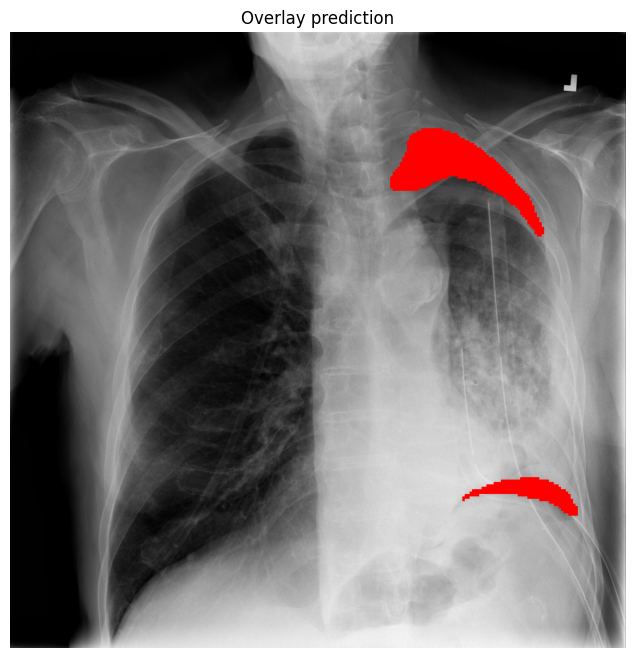

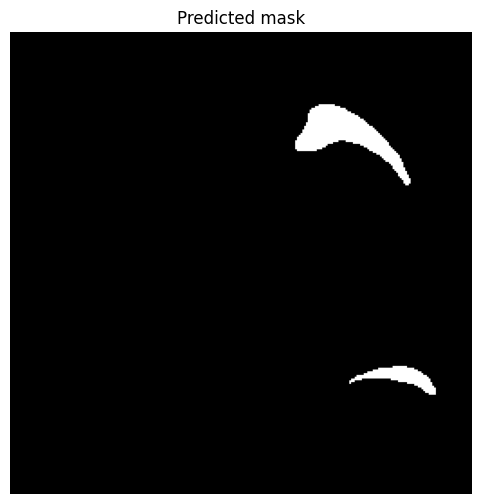

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

overlay_path = result.get("overlay_path")
mask_path = result.get("mask_path")

print("overlay_path =", overlay_path)
print("mask_path =", mask_path)

if overlay_path and Path(overlay_path).exists():
    img = Image.open(overlay_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Overlay prediction")
    plt.show()

if mask_path and Path(mask_path).exists():
    img = Image.open(mask_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Predicted mask")
    plt.show()

In [10]:
from pathlib import Path

pred_dir = Path("artifacts/service_predictions")
if pred_dir.exists():
    for p in sorted(pred_dir.glob("*")):
        print(p)
else:
    print("Prediction directory does not exist yet")

artifacts/service_predictions/.ipynb_checkpoints
artifacts/service_predictions/a1c6e1f9d6fb_mask.png
artifacts/service_predictions/a1c6e1f9d6fb_overlay.png
artifacts/service_predictions/fa26797aedd6_mask.png
artifacts/service_predictions/fa26797aedd6_overlay.png


In [11]:
# Вызывать только если сервер был запущен из этого ноутбука
if server is not None and server.poll() is None:
    server.terminate()
    server.wait()
    print("Server stopped")
else:
    print("No local server process to stop from this notebook")

Server stopped
